In [5]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([53, 22, 45, 47, 21, 59, 60, 40, 25])
y = np.array([500, 45, 150, 160, 47, 580, 600, 155, 50])

In [3]:
data = np.column_stack((x, y))

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

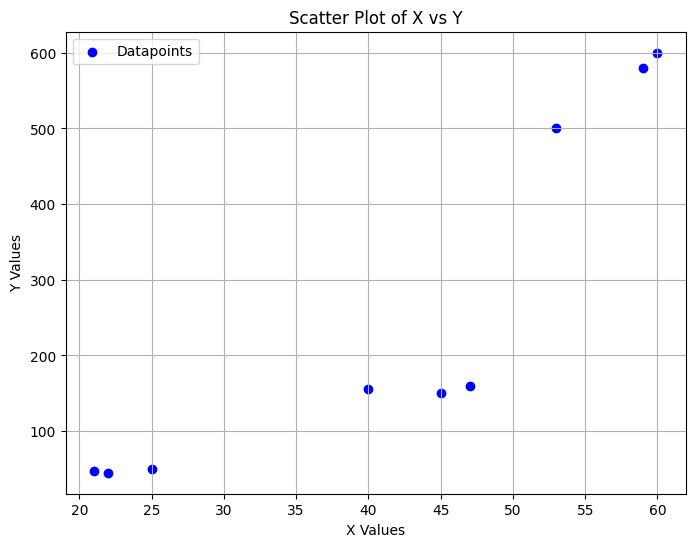

In [ ]:
plt.figure(figsize=(8, 6)) 
plt.scatter(x, y, color='blue', label='Datapoints')  
plt.title('Scatter Plot of X vs Y')  
plt.xlabel('X Values')  
plt.ylabel('Y Values')  
plt.legend() 
plt.grid(True)  
plt.show() 

In [4]:
data

array([[ 53, 500],
       [ 22,  45],
       [ 45, 150],
       [ 47, 160],
       [ 21,  47],
       [ 59, 580],
       [ 60, 600],
       [ 40, 155],
       [ 25,  50]])

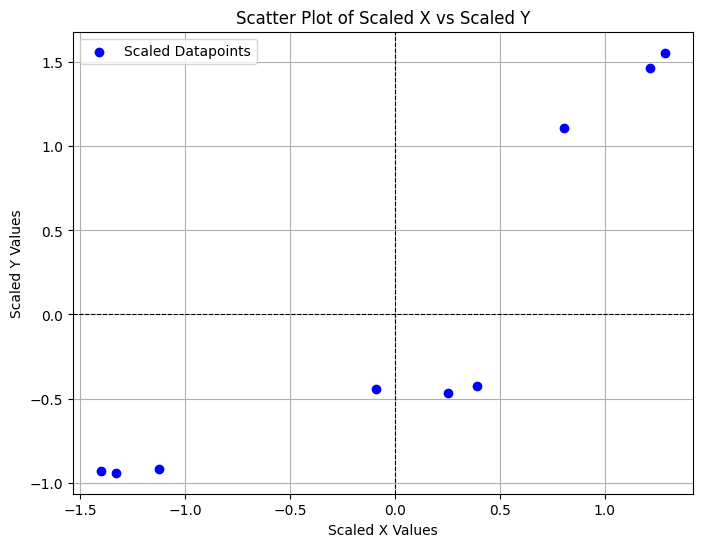

In [ ]:
x_scaled = data_scaled[:, 0]  
y_scaled = data_scaled[:, 1]  


plt.figure(figsize=(8, 6))
plt.scatter(x_scaled, y_scaled, color='blue', label='Scaled Datapoints')
plt.title('Scatter Plot of Scaled X vs Scaled Y')
plt.xlabel('Scaled X Values')
plt.ylabel('Scaled Y Values')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # 
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)  
plt.legend()
plt.grid(True)
plt.show()

In [11]:
clustering = AgglomerativeClustering(n_clusters=1, linkage='ward')
labels = clustering.fit_predict(data_scaled)

In [12]:
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0])

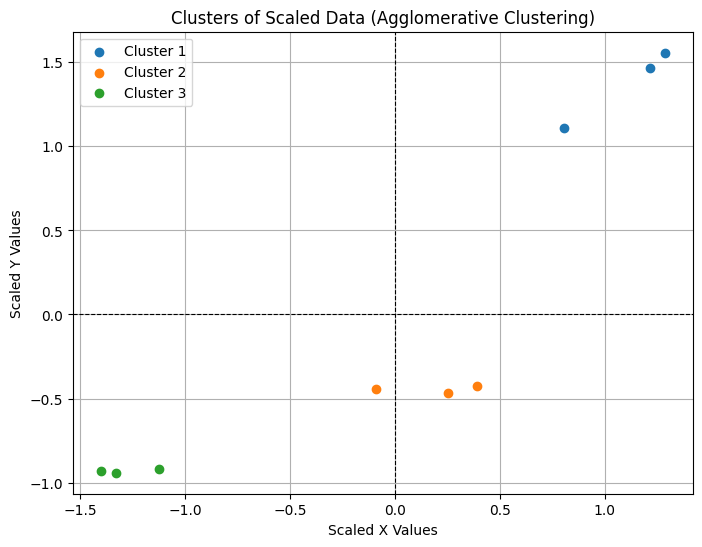

In [ ]:
plt.figure(figsize=(8, 6))
for cluster in range(3):  
    plt.scatter(
        x_scaled[labels == cluster],  
        y_scaled[labels == cluster],  
        label=f'Cluster {cluster + 1}'  
    )
plt.title('Clusters of Scaled Data (Agglomerative Clustering)')
plt.xlabel('Scaled X Values')
plt.ylabel('Scaled Y Values')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)  
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
labels

array([0, 2, 1, 1, 2, 0, 0, 1, 2], dtype=int32)

In [ ]:

def calculate_sse(data, labels, centroids):
    sse = 0
    for cluster in range(len(centroids)):

        cluster_points = data[labels == cluster]

        squared_distances = np.sum((cluster_points - centroids[cluster]) ** 2, axis=1)

        sse += np.sum(squared_distances)
    return sse

centroids = []
for cluster in range(3):
    centroid = np.mean(data_scaled[labels == cluster], axis=0)
    centroids.append(centroid)
centroids = np.array(centroids)


sse_total = calculate_sse(data_scaled, labels, centroids)


for cluster in range(3):
    cluster_points = data_scaled[labels == cluster]
    squared_distances = np.sum((cluster_points - centroids[cluster]) ** 2, axis=1)
    sse_cluster = np.sum(squared_distances)
    print(f"SSE for Cluster {cluster + 1}: {sse_cluster:.2f}")

print(f"Total SSE: {sse_total:.2f}")

SSE for Cluster 1: 0.25
SSE for Cluster 2: 0.04
SSE for Cluster 3: 0.12
Total SSE: 0.42


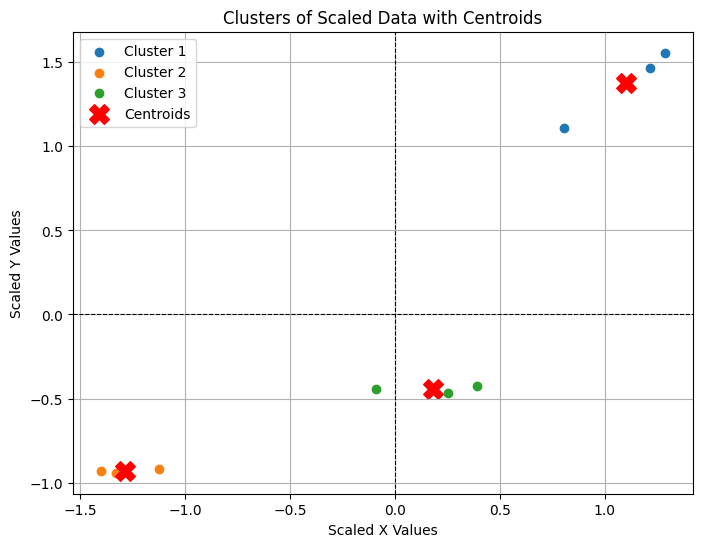

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
for cluster in range(3):
    plt.scatter(
        data_scaled[labels == cluster, 0],  
        data_scaled[labels == cluster, 1],  
        label=f'Cluster {cluster + 1}'
    )

plt.scatter(
    centroids[:, 0],  
    centroids[:, 1],  
    color='red',  
    marker='X',  
    s=200,  
    label='Centroids'
)
plt.title('Clusters of Scaled Data with Centroids')
plt.xlabel('Scaled X Values')
plt.ylabel('Scaled Y Values')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  
plt.axvline(0, color='black', linestyle='--', linewidth=0.8) 
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def calculate_sse(X, labels, num_clusters):
    sse = 0
    for i in range(num_clusters):
        cluster_points = X[labels == i]


        centroid = np.mean(cluster_points, axis=0)

        sse += np.sum(np.linalg.norm(cluster_points - centroid, axis=1) ** 2)
    return sse

In [21]:
sse_values = []

for num_clusters in range(1, 4):
    clustering = AgglomerativeClustering(n_clusters=num_clusters, linkage='single')
    labels = clustering.fit_predict(data_scaled)

    sse = calculate_sse(data_scaled, labels, num_clusters)
    sse_values.append(sse)

In [22]:
for i, sse in enumerate(sse_values, 1):
    print(f"SSE for {i} clusters: {sse}")

SSE for 1 clusters: 18.0
SSE for 2 clusters: 4.0045419610788695
SSE for 3 clusters: 0.41507227953540105


In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [27]:
Z = linkage(data_scaled, method='ward')

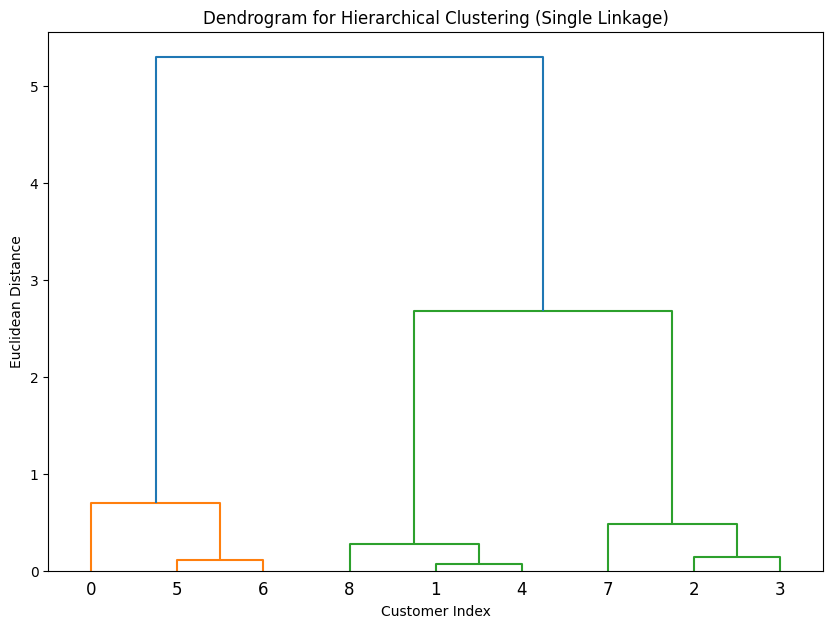

In [28]:
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram for Hierarchical Clustering (Single Linkage)')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance')
plt.show()